t+3 
full 
有异常检测  
有滞后特征

In [1]:
import pandas as pd
import os
from sklearn.svm import SVR
from glob import glob
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt
from features_hr4 import features
from imblearn.over_sampling import SMOTE
from collections import Counter


path=r"D:\WorkPlace\A_Data\Ca\选择3x3\motion\win4_4\C"
input_folder = r"D:\WorkPlace\A_Data\input_folder"

# 挑选出3天pam的值
final_file_path = os.path.join(path, "final.csv")
filtered_file_path = os.path.join(path, "final0.7.csv")
output_abnormal = os.path.join(path, "异常值编码")
output_hysteresis = os.path.join(path, "滞后特征")

# 主循环中传递滞后窗口大小
lag_window = 7  # 可以灵活调整滞后窗口大小
predict_horizon = 3  # 预测几天后的 pam 变化，例如2表示 t+2


# 1. 创建滞后特征 ==========

In [2]:
features = features  # 假设您有这些特征

input_files = glob(os.path.join(input_folder, "*.csv"))
all_data = []

os.makedirs(output_hysteresis, exist_ok=True)

# 定义滞后特征提取函数
def extract_lagged_features(df, required_columns, lag_window, predict_horizon):
    rows = []
    for i in range(lag_window, len(df)):
        pam_t = df.loc[i, "pam"]
        if i + predict_horizon >= len(df):
            break

        pam_t_future = df.loc[i + predict_horizon, "pam"]

        if pd.isna(pam_t) or pd.isna(pam_t_future):
            continue

        # 提取 t-lag_window 到 t 的特征
        lagged_features = [df.loc[i - j, required_columns] for j in range(lag_window, -1, -1)]
        rolling_window = pd.DataFrame(lagged_features)

        # 计算统计特征
        rolling_mean = rolling_window.mean()
        rolling_std = rolling_window.std()
        rolling_skew = rolling_window.skew()

        # 构造特征行
        row = (list(rolling_window.values.flatten())
               + rolling_mean.tolist()
               + rolling_std.tolist()
               + rolling_skew.tolist()
               + [pam_t_future - pam_t])  # 目标值为 t+horizon 的变化
        rows.append(row)
    return rows

# 主循环处理所有输入文件
for file in input_files:
    df = pd.read_csv(file)
    required_columns = [col for col in features if col in df.columns]

    rows = extract_lagged_features(df, required_columns, lag_window, predict_horizon)

    if rows:
        # 构建列名
        columns = (
            [f"{col}_t-{i}" for i in range(lag_window, -1, -1) for col in required_columns]
            + [f"{col}_mean" for col in required_columns]
            + [f"{col}_std" for col in required_columns]
            + [f"{col}_skew" for col in required_columns]
            + ["target"]
        )

        output_df = pd.DataFrame(rows, columns=columns)
        output_file = os.path.join(output_hysteresis, os.path.basename(file))
        output_df.to_csv(output_file, index=False)
        all_data.append(output_df)

# 2. 异常值编码 ==========

In [3]:
input_folder = output_hysteresis
os.makedirs(output_abnormal, exist_ok=True)

input_files = glob(os.path.join(input_folder, "*.csv"))

for file in input_files:
    data = pd.read_csv(file)
    data.fillna(-1, inplace=True)  # 用 -1RF 填充缺失值
    encoded_columns = {}

    isolation_forest = IsolationForest(contamination=0.05, random_state=42)#IsolationForest 不支持数据中存在 NaN 值，因此需要在调用 fit_predict 前对数据进行处理，
    anomaly_scores = isolation_forest.fit_predict(data.drop(columns=['target']))
    data['anomaly'] = anomaly_scores


    for column in data.columns:
        if column == "target":
            continue

        if pd.api.types.is_numeric_dtype(data[column]):
            Q1 = data[column].quantile(0.25)
            Q3 = data[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            encoded_columns[f"{column}_encoded"] = data[column].apply(
                lambda x: 0 if x < lower_bound else (2 if x > upper_bound else 1)
            )

    encoded_data = pd.DataFrame(encoded_columns)
    final_data = pd.concat([data, encoded_data], axis=1)
    final_file_path = os.path.join(output_abnormal, os.path.basename(file))
    final_data.to_csv(final_file_path, index=False)


# 3. 合成 Final 文件 ==========

In [4]:
directory_path = output_abnormal

final_df = pd.DataFrame()
for file_name in os.listdir(directory_path):
    if file_name.endswith(".csv"):
        file_path = os.path.join(directory_path, file_name)
        df = pd.read_csv(file_path)
        final_df = pd.concat([final_df, df], ignore_index=True)

final_df.to_csv(final_file_path, index=False)


# 4. 筛选缺失值 ==========

In [5]:
sensor_data = pd.read_csv(final_file_path)
missing_percentage = sensor_data.isnull().mean() * 100
selected_columns = missing_percentage[missing_percentage <= 30].index.tolist()
filtered_data = sensor_data[selected_columns]
filtered_data.to_csv(filtered_file_path, index=False)

# 5. 数据增强与训练 ==========

In [6]:
data = pd.read_csv(filtered_file_path)
sensor_columns = [col for col in data.columns if col not in ['target']]
data[sensor_columns] = data[sensor_columns].apply(pd.to_numeric, errors='coerce')
data[sensor_columns] = data[sensor_columns].fillna(data[sensor_columns].mean())

# 标准化
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[sensor_columns])
X = pd.DataFrame(scaled_features, columns=sensor_columns)
y = data['target']

In [7]:
# 数据增强
# 计算每个类别的样本数
class_counts = Counter(y)

# 定义采样策略：对所有类别增加 1RF.05 倍
sampling_strategy = {label: int(class_counts[label] * 1.5) for label in class_counts}

# ADASYN 对全部类别进行采样
adasyn = ADASYN(sampling_strategy='not majority', n_neighbors=3, random_state=42,)
X_resampled, y_resampled = adasyn.fit_resample(X, y)

# 对极端值单独处理
extreme_samples = (np.abs(y) > y.mean() + 2 * y.std())
X_extreme, y_extreme = X[extreme_samples], y[extreme_samples]

# 定义极端值的采样策略
extreme_sampling_strategy = {label: int(len(y_extreme) * 2) for label in set(y_extreme)}

# 使用 SMOTE 增强极端样本
smote_extreme = SMOTE(sampling_strategy=extreme_sampling_strategy, random_state=42, k_neighbors=3)
X_extreme_resampled, y_extreme_resampled = smote_extreme.fit_resample(X_extreme, y_extreme)

# 合并增强后的数据
X_resampled = np.vstack([X_resampled, X_extreme_resampled])
y_resampled = np.hstack([y_resampled, y_extreme_resampled])


d:\Anaconda_Conda\envs\py39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\Anaconda_Conda\envs\py39\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\Anaconda_Conda\envs\py39\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "d:\Anaconda_Conda\envs\py39\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\Anaconda_Conda\envs\py39\lib\sub

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

base_models = [
    ('xgb', XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=8,
        random_state=42
    )),

    ('svm', SVR(C=1.0, kernel='rbf')),
     ('rf', RandomForestRegressor(n_estimators=200, random_state=42))
]

In [9]:
meta_model = CatBoostRegressor(
    n_estimators=300,
    learning_rate=0.03,
    loss_function='MAE',
    depth=10,
    l2_leaf_reg=3,
    random_state=42
)

model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model
)

In [10]:
model.fit(X_train, y_train)

0:	learn: 8.4259731	total: 86.2ms	remaining: 25.8s
1:	learn: 8.2308538	total: 119ms	remaining: 17.7s
2:	learn: 8.0505983	total: 149ms	remaining: 14.8s
3:	learn: 7.8687838	total: 181ms	remaining: 13.4s
4:	learn: 7.6942605	total: 210ms	remaining: 12.4s
5:	learn: 7.5237867	total: 239ms	remaining: 11.7s
6:	learn: 7.3605730	total: 265ms	remaining: 11.1s
7:	learn: 7.1992330	total: 292ms	remaining: 10.7s
8:	learn: 7.0448963	total: 319ms	remaining: 10.3s
9:	learn: 6.8981423	total: 349ms	remaining: 10.1s
10:	learn: 6.7539038	total: 376ms	remaining: 9.87s
11:	learn: 6.6150935	total: 406ms	remaining: 9.74s
12:	learn: 6.4802768	total: 437ms	remaining: 9.64s
13:	learn: 6.3538582	total: 464ms	remaining: 9.48s
14:	learn: 6.2285059	total: 491ms	remaining: 9.33s
15:	learn: 6.1090470	total: 516ms	remaining: 9.16s
16:	learn: 5.9929913	total: 545ms	remaining: 9.08s
17:	learn: 5.8799380	total: 575ms	remaining: 9.01s
18:	learn: 5.7699152	total: 599ms	remaining: 8.85s
19:	learn: 5.6628422	total: 629ms	remain

StackingRegressor(estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_ra...
                                            max_delta_step=None, max_depth=8,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                              ('svm', SVR()),
                              ('rf',
                               RandomForestRegressor(n_estimators=200,
                                                     random_state=42))],
                  final_estimator=<catboost.core.CatBoostRegressor object at 0x00000238BBD87C40>)

# 6. 评估与可视化 ==========


In [11]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"\n测试集上的均方误差（MSE）：{mse}")

# 极端值样本评估
threshold = 2.0
errors = np.abs(y_pred - y_test)
correct_predictions = errors <= threshold

extreme_samples = (np.abs(y_test) > 10)
extreme_mse = mean_squared_error(y_test[extreme_samples], y_pred[extreme_samples])

print(f"\n误差在 {threshold} 范围内的准确率：{np.mean(correct_predictions) * 100:.2f}%")
print(f"极端值样本的MSE：{extreme_mse}")



测试集上的均方误差（MSE）：20.616999585684656

误差在 2.0 范围内的准确率：64.78%
极端值样本的MSE：17.258273014234636


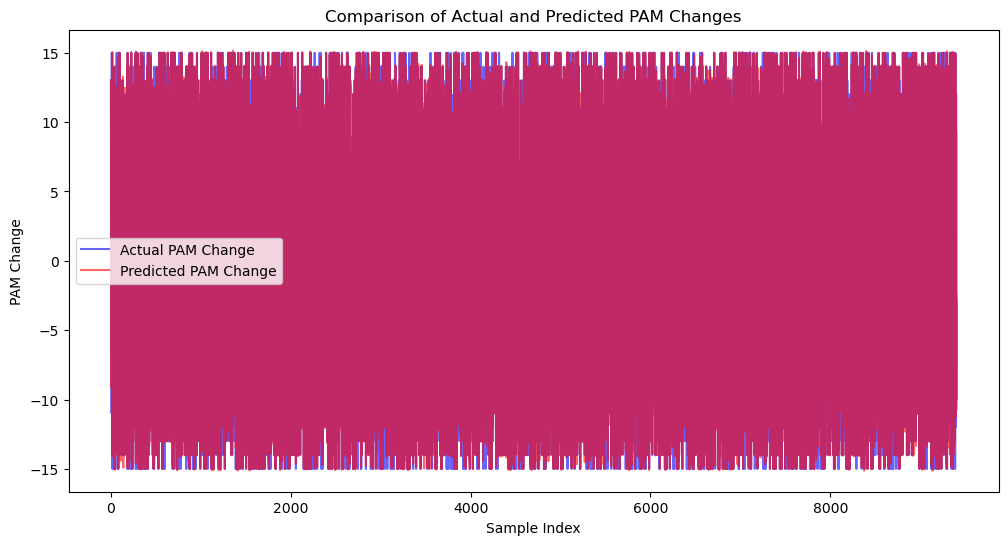

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual PAM Change", color="blue", alpha=0.6)
plt.plot(y_pred, label="Predicted PAM Change", color="red", alpha=0.6)
plt.legend()
plt.title("Comparison of Actual and Predicted PAM Changes")
plt.xlabel("Sample Index")
plt.ylabel("PAM Change")
plt.show()
